# Economic Results

Two deliverables, both built purely from the already-collected evaluation data
(`8_testing/results/raw_daily/` + `8_testing/results/cross_eval/`) -- no new training or
evaluation run needed.

1. **Economic results tables** -- one per market (single-price, dual-price). Each has 4
   rows (baseline, CRPS-only control, DFL single-price, DFL dual-price) and 6 columns:
   mean/std ACROSS SEEDS of (mean daily total cost, mean daily imbalance cost `C_imb`,
   mean daily absolute imbalance `imbalance_volume_abs_MWh`). Each DFL row is native in one
   table and cross-evaluated in the other -- same 4-row structure as the Results chapter's
   Table 4.1/4.2, extended with the imbalance-cost and imbalance-volume columns.
2. **Economic vs. forecast-quality scatter** -- two graphs (one per market), each point one
   forecaster-seed's (mean daily CRPS, mean daily total cost) under that market, coloured by
   forecaster family. Baseline contributes 1 point per market (not seed-averaged); control
   and each DFL arm contribute 5 (one per seed). A checkpoint's CRPS is identical in both
   graphs (a fixed property of the forecaster); only its y-position (cost) differs by market.

**Caveat worth keeping in mind when reading the imbalance-cost column**: single-price's
`C_imb` is signed (can be negative -- a revenue) while dual-price's `C_imb` is always >= 0
by construction. The column is meaningful comparing rows *within* one table (same
settlement formula throughout), but is not on a directly comparable scale *between* the
two tables.

## Setup

In [1]:
from __future__ import annotations
import re
import sys
from pyprojroot import here
sys.path.insert(0, str(here() / "8_testing"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from eval_raw import RAW_DAILY_DIR

CROSS_EVAL_DIR = here() / "8_testing" / "results" / "cross_eval"
SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801
FAMILY_ORDER = ["Baseline", "Control", "DFL single-price", "DFL dual-price"]
FAMILY_COLORS = {"Baseline": "C0", "Control": "grey", "DFL single-price": "C6", "DFL dual-price": "C3"}

pd.set_option("display.width", 160)

### Load and label

Combines native (`raw_daily/`) and cross-evaluated (`cross_eval/`) per-day results into one
table, deriving `family` (which of the 4 forecaster types) and `seed` from each
`forecaster_id` string. `market` is always the price-mode pipeline the row was actually
*evaluated* under (for cross-eval rows this is the non-native structure), matching the
"which table does this row belong to" question directly.

In [2]:
def family_of(base_id: str) -> str:
    if base_id == "baseline":
        return "Baseline"
    if base_id.startswith("crps_only_retrained"):
        return "Control"
    if base_id.startswith("dfl_1stage_single-price"):
        return "DFL single-price"
    if base_id.startswith("dfl_1stage_dual-price"):
        return "DFL dual-price"
    raise ValueError(f"unrecognised forecaster_id base: {base_id!r}")


def seed_of(forecaster_id: str) -> int:
    m = re.search(r"_seed(\d+)", forecaster_id)
    return int(m.group(1)) if m else DEFAULT_SEED


KEEP_COLS = ["forecaster_id", "price_mode", "day", "total_cost", "C_da", "C_imb",
             "imbalance_volume_abs_MWh", "crps", "throughput_MWh", "p_ch_r", "p_dis_r"]

native = pd.read_parquet(RAW_DAILY_DIR, columns=KEEP_COLS)
native["role"] = "native"

cross = pd.read_parquet(CROSS_EVAL_DIR, columns=KEEP_COLS)
cross["role"] = "cross-eval"

all_df = pd.concat([native, cross], ignore_index=True)
# forecaster_id's cross-eval suffix ("_ON_single-price"/"_ON_dual-price") carries no
# family/seed information beyond what precedes it -- strip it before parsing.
all_df["base_id"] = all_df["forecaster_id"].str.replace(r"_ON_(single|dual)-price$", "", regex=True)
all_df["family"] = all_df["base_id"].apply(family_of)
all_df["seed"] = all_df["base_id"].apply(seed_of)
all_df["market"] = all_df["price_mode"]   # the evaluated pipeline, native or not

print(f"all_df: {len(all_df)} rows | families: {sorted(all_df['family'].unique())} | "
      f"markets: {sorted(all_df['market'].unique())}")
print(all_df.groupby(["market", "family", "role"]).agg(n_seeds=("seed", "nunique"), n_days=("day", "size")))

all_df: 11712 rows | families: ['Baseline', 'Control', 'DFL dual-price', 'DFL single-price'] | markets: ['dual-price', 'single-price']
                                          n_seeds  n_days
market       family           role                       
dual-price   Baseline         native            1     366
             Control          native            5    1830
             DFL dual-price   native            5    1830
             DFL single-price cross-eval        5    1830
single-price Baseline         native            1     366
             Control          native            5    1830
             DFL dual-price   cross-eval        5    1830
             DFL single-price native            5    1830


## Economic results tables

In [3]:
def win_rate_vs_baseline(sub: pd.DataFrame, family: str) -> tuple[float, float]:
    """(mean, std) of the fraction of days this family's total_cost beats (is lower
    than) Baseline's total_cost, matched by day within the same market. Hierarchical:
    computed per seed first, then mean/std across seeds (matching this project's
    seed-averaging convention). (NaN, NaN) for Baseline's own row (a comparison against
    itself is not meaningful)."""
    if family == "Baseline":
        return np.nan, np.nan
    baseline_by_day = sub.loc[sub["family"] == "Baseline"].set_index("day")["total_cost"]
    fam = sub[sub["family"] == family]
    seed_rates = []
    for seed, grp in fam.groupby("seed"):
        fam_by_day, base_by_day = grp.set_index("day")["total_cost"].align(baseline_by_day, join="inner")
        seed_rates.append((fam_by_day < base_by_day).mean())
    seed_rates = np.array(seed_rates)
    return float(seed_rates.mean()), (float(seed_rates.std()) if len(seed_rates) > 1 else np.nan)


def market_table(market: str) -> pd.DataFrame:
    """4 rows (Baseline, Control, DFL single-price, DFL dual-price). Columns, in order:
    win-rate vs baseline mean/std (fraction of days beating Baseline's total_cost,
    matched by day, hierarchical per-seed then across-seed), then mean/std ACROSS SEEDS
    of each seed's own mean-daily value for total_cost / C_da / C_imb /
    imbalance_volume_abs_MWh / crps. Baseline is a single fixed checkpoint (n=1) -- std
    is NaN throughout its row. CRPS is price-mode-independent per checkpoint (a fixed
    property of the forecaster, not the settlement it's dispatched under), so its
    mean/std here is the same whether computed under this market's rows or the other's
    -- included per-table anyway so both tables are fully self-contained."""
    sub = all_df[all_df["market"] == market]
    rows = []
    for family in FAMILY_ORDER:
        fam = sub[sub["family"] == family]
        per_seed = fam.groupby("seed").agg(
            mean_total_cost=("total_cost", "mean"),
            mean_C_da=("C_da", "mean"),
            mean_C_imb=("C_imb", "mean"),
            mean_abs_imb=("imbalance_volume_abs_MWh", "mean"),
            mean_crps=("crps", "mean"),
        )
        has_std = len(per_seed) > 1
        win_rate_mean, win_rate_std = win_rate_vs_baseline(sub, family)
        rows.append({
            "forecaster": family,
            "win_rate_vs_baseline": win_rate_mean,
            "std_win_rate_vs_baseline": win_rate_std,
            "mean_daily_total_cost": per_seed["mean_total_cost"].mean(),
            "std_daily_total_cost": per_seed["mean_total_cost"].std() if has_std else np.nan,
            "mean_daily_da_cost": per_seed["mean_C_da"].mean(),
            "std_daily_da_cost": per_seed["mean_C_da"].std() if has_std else np.nan,
            "mean_daily_imbalance_cost": per_seed["mean_C_imb"].mean(),
            "std_daily_imbalance_cost": per_seed["mean_C_imb"].std() if has_std else np.nan,
            "mean_daily_abs_imbalance_MWh": per_seed["mean_abs_imb"].mean(),
            "std_daily_abs_imbalance_MWh": per_seed["mean_abs_imb"].std() if has_std else np.nan,
            "mean_crps": per_seed["mean_crps"].mean(),
            "std_crps": per_seed["mean_crps"].std() if has_std else np.nan,
        })
    return pd.DataFrame(rows).set_index("forecaster")


single_price_table = market_table("single-price")
dual_price_table = market_table("dual-price")

print("=== Single-price market ===")
display(single_price_table.round(4))
print("\n=== Dual-price market ===")
display(dual_price_table.round(4))

=== Single-price market ===


,win_rate_vs_baseline,std_win_rate_vs_baseline,mean_daily_total_cost,std_daily_total_cost,mean_daily_da_cost,std_daily_da_cost,mean_daily_imbalance_cost,std_daily_imbalance_cost,mean_daily_abs_imbalance_MWh,std_daily_abs_imbalance_MWh,mean_crps,std_crps
forecaster,,,,,,,,,,,,
Baseline,NaN,NaN,1746.5462,NaN,1832.0071,NaN,-85.4609,NaN,8.7532,NaN,0.2677,NaN
Control,0.5497,0.0287,1744.7383,1.4007,1796.4327,26.1453,-51.6944,25.0697,8.6544,0.1484,0.2665,0.0060
DFL single-price,0.5536,0.0094,1744.3488,1.6599,1782.7829,39.7539,-38.4341,38.3117,8.5746,0.2079,0.2643,0.0071
DFL dual-price,0.5426,0.0252,1745.2268,0.8422,1810.7165,21.9684,-65.4898,21.5298,8.7239,0.1290,0.2693,0.0059



=== Dual-price market ===


,win_rate_vs_baseline,std_win_rate_vs_baseline,mean_daily_total_cost,std_daily_total_cost,mean_daily_da_cost,std_daily_da_cost,mean_daily_imbalance_cost,std_daily_imbalance_cost,mean_daily_abs_imbalance_MWh,std_daily_abs_imbalance_MWh,mean_crps,std_crps
forecaster,,,,,,,,,,,,
Baseline,NaN,NaN,1797.5437,NaN,1835.3426,NaN,-37.7989,NaN,8.4789,NaN,0.2677,NaN
Control,0.5355,0.0697,1795.8248,1.1893,1799.3890,26.1834,-3.5642,25.1617,8.3800,0.1617,0.2665,0.0060
DFL single-price,0.5650,0.0490,1795.2698,1.7829,1785.7682,39.7775,9.5016,38.0212,8.2893,0.2220,0.2643,0.0071
DFL dual-price,0.4934,0.0659,1796.7334,0.8277,1813.8454,21.9686,-17.1120,21.1779,8.4483,0.1403,0.2693,0.0059


## Realised throughput table

`throughput_MWh` (already in `raw_daily`/`cross_eval`) is the sum of realised charge and
discharge actions over the day, `sum((p_ch_r + p_dis_r) * dt)` -- total energy physically
moved through the battery, charge and discharge added together rather than netted. One
row per forecaster, mean/std ACROSS SEEDS of each seed's own mean-daily throughput,
matching the same hierarchical convention as the economic tables above. Baseline is a
single fixed checkpoint (n=1), so it carries no std.

In [4]:
def throughput_table(market: str) -> pd.DataFrame:
    """4 rows (Baseline, Control, DFL single-price, DFL dual-price): mean/std ACROSS
    SEEDS of each seed's own mean-daily throughput_MWh (sum of realised charge +
    discharge actions)."""
    sub = all_df[all_df["market"] == market]
    rows = []
    for family in FAMILY_ORDER:
        fam = sub[sub["family"] == family]
        per_seed = fam.groupby("seed")["throughput_MWh"].mean()
        has_std = len(per_seed) > 1
        rows.append({
            "forecaster": family,
            "mean_daily_throughput_MWh": per_seed.mean(),
            "std_daily_throughput_MWh": per_seed.std() if has_std else np.nan,
        })
    return pd.DataFrame(rows).set_index("forecaster")


single_price_throughput = throughput_table("single-price")
dual_price_throughput = throughput_table("dual-price")

print("=== Single-price market ===")
display(single_price_throughput.round(4))
print("\n=== Dual-price market ===")
display(dual_price_throughput.round(4))

=== Single-price market ===


,mean_daily_throughput_MWh,std_daily_throughput_MWh
forecaster,,
Baseline,18.7503,NaN
Control,18.7503,0.0
DFL single-price,18.7503,0.0
DFL dual-price,18.7503,0.0



=== Dual-price market ===


,mean_daily_throughput_MWh,std_daily_throughput_MWh
forecaster,,
Baseline,19.0381,NaN
Control,19.0373,0.0265
DFL single-price,19.0411,0.0244
DFL dual-price,19.0395,0.0268


## Compare economic and forecast-quality results

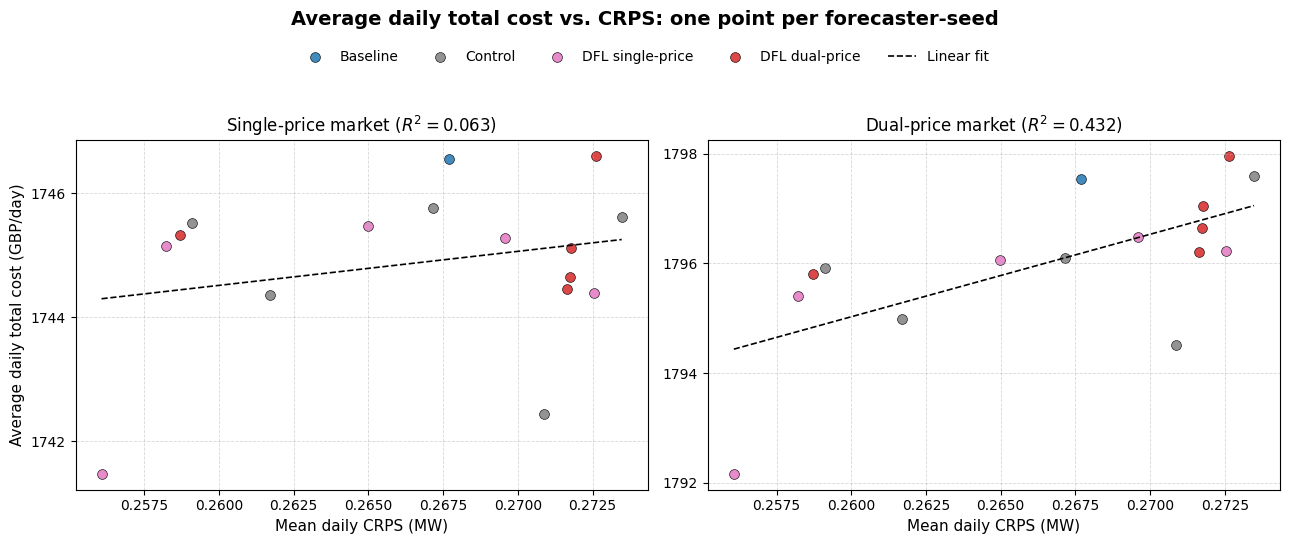

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def per_seed_points(market: str) -> pd.DataFrame:
    """One row per (family, seed) evaluated under `market`: mean daily CRPS (x) and mean
    daily total cost (y) -- the per-seed analogue of market_table's aggregated rows."""
    sub = all_df[all_df["market"] == market]
    return sub.groupby(["family", "seed"]).agg(
        mean_crps=("crps", "mean"),
        mean_total_cost=("total_cost", "mean"),
    ).reset_index()

def plot_cost_vs_crps(ax, market: str):
    pts = per_seed_points(market)
    for family in FAMILY_ORDER:
        fam_pts = pts[pts["family"] == family]
        ax.scatter(fam_pts["mean_crps"], fam_pts["mean_total_cost"],
                   color=FAMILY_COLORS[family], label=family, s=50, alpha=0.85,
                   edgecolors="black", linewidths=0.5)

    # Linear fit + R^2 across ALL points in this panel (every family/seed pooled
    # together, including Baseline), matching this project's established
    # solar-bias-scatter convention (forecaster_tables.ipynb). R^2 differs per panel,
    # so it goes in that panel's own title, not the shared external legend.
    x, y = pts["mean_crps"].to_numpy(), pts["mean_total_cost"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, slope * xs + intercept, "k--", linewidth=1.2, label="Linear fit")

    ax.set_xlabel("Mean daily CRPS (MW)", fontsize=11)
    ax.set_title(f"{market.capitalize()} market ($R^2={r2:.3f}$)", fontsize=12)
    ax.grid(linestyle="--", linewidth=0.6, alpha=0.5)
    
    # 1. NEW: Force Matplotlib to use a maximum of ~5 evenly spaced ticks on the y-axis
    ax.locator_params(axis='y', nbins=5)

# Removed sharey=True so each market can scale dynamically to show internal spread
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# 2. UPDATED: Increased wspace slightly so the right-hand y-axis numbers have room to print
fig.subplots_adjust(wspace=0.2)

plot_cost_vs_crps(axes[0], "single-price")
plot_cost_vs_crps(axes[1], "dual-price")

# Retain the single y-axis label on the leftmost plot to prevent visual redundancy
axes[0].set_ylabel("Average daily total cost (GBP/day)", fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=5, frameon=False)

fig.suptitle("Average daily total cost vs. CRPS: one point per forecaster-seed", fontsize=14, fontweight="bold")

fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

## Day-ahead vs. imbalance cost, per arm

For each arm (Baseline, Control, DFL single-price, DFL dual-price) and each market, two
bars side by side on one shared axis: day-ahead cost (`C_da`) from 0, and imbalance cost
(`C_imb`) starting from the height `C_da` reaches -- so the imbalance bar visually
"continues" where day-ahead leaves off, its far edge landing exactly at `total_cost`
(marked with a diamond, matching the tables' `mean_daily_total_cost` column exactly).
Since the two bars sit at different x-positions (not stacked at the same x), this reads
cleanly even though `C_imb` is small relative to `C_da`. The y-axis is truncated (not
starting at 0) so this transition is legible -- `C_da` (~1780-1835 GBP/day) dominates the
full 0-scale, and the region that actually varies sits in a much narrower band. Error
bars are each bar's own across-seed std (Baseline is a single fixed checkpoint, so it
carries none).

## Spread between day-ahead cost and imbalance cost, per arm

`spread = C_da - C_imb`, computed **per seed** (that seed's own mean daily `C_da` minus
its own mean daily `C_imb`, i.e. paired within the same seed) before aggregating, then
reported as mean +/- std of that per-seed spread across the 5 seeds -- the same
hierarchical per-seed-first convention used throughout this notebook, and not the same
thing as combining the tables' separately-reported `std_daily_da_cost` and
`std_daily_imbalance_cost` (which would ignore any correlation between a seed's own DA
and imbalance cost). Baseline is a single fixed checkpoint (n=1), so it carries no error
bar. Since `C_imb` is small relative to `C_da` (see the previous figure), spread tracks
`C_da` closely but is shifted up by however positive/negative that arm's imbalance cost
is.

## Day-ahead, imbalance, and total cost change vs. Baseline, per retrained arm

For each retrained arm (Control, DFL single-price, DFL dual-price) and each market, three
bars, each a per-seed difference vs. Baseline (that seed's own mean daily value minus
Baseline's single fixed value, mean +/- std across the 5 seeds): `delta_C_da`,
`delta_C_imb`, and `delta_total_cost = delta_C_da + delta_C_imb` (the actual bottom-line
change, matching the tables' `mean_daily_total_cost` deltas). Baseline itself is excluded
(comparing it to itself is zero by definition). The zero line marks "no change vs
Baseline" for all three bars.

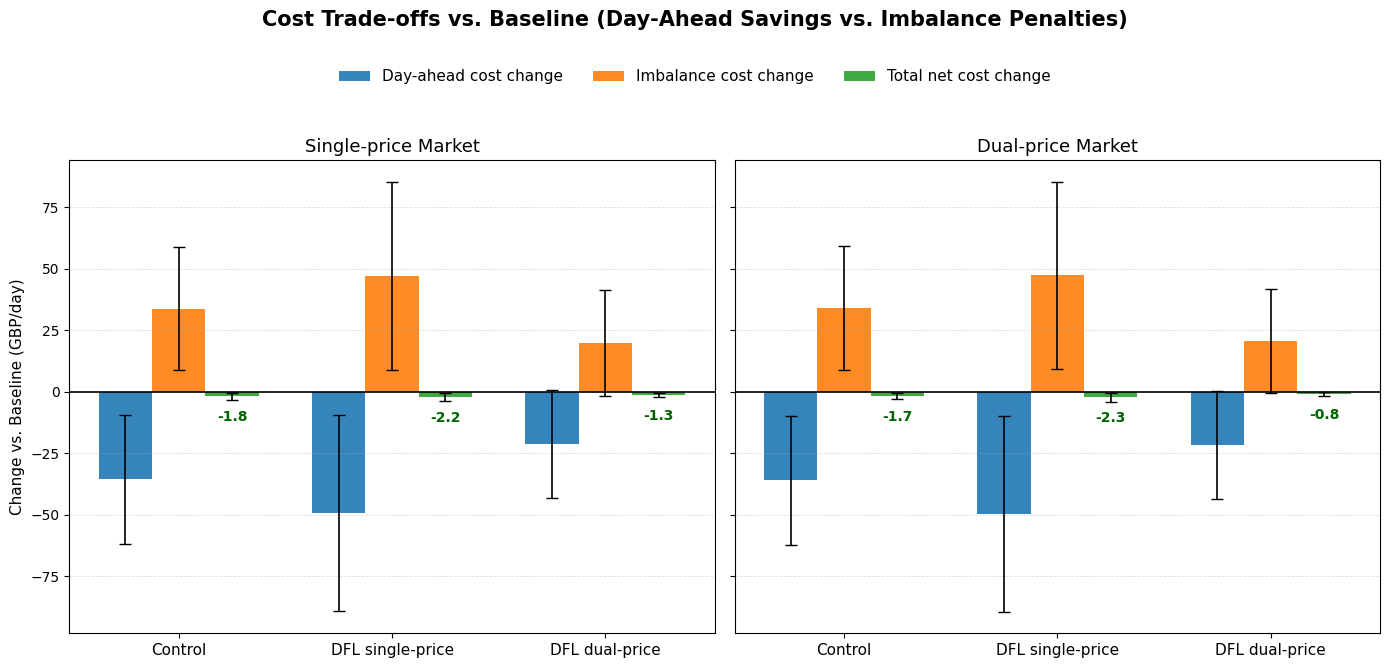

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# (Assuming all_df and RETRAIN_ARMS are already defined in your environment)
RETRAIN_ARMS = ["Control", "DFL single-price", "DFL dual-price"]
DA_COLOR = "C0"
IMB_COLOR = "C1"
TOTAL_COLOR = "C2"
METRICS = ["da", "imb", "total"]
METRIC_COLORS = {"da": DA_COLOR, "imb": IMB_COLOR, "total": TOTAL_COLOR}

# 1. Cleaned up the legend labels for a more professional look
METRIC_LABELS = {
    "da": "Day-ahead cost change",
    "imb": "Imbalance cost change",
    "total": "Total net cost change",
}
BAR_WIDTH = 0.25

def delta_vs_baseline_stats(market: str, family: str) -> dict[str, tuple[float, float]]:
    # Your logic is unchanged here
    sub = all_df[all_df["market"] == market]
    baseline_da = sub.loc[sub["family"] == "Baseline", "C_da"].mean()
    baseline_imb = sub.loc[sub["family"] == "Baseline", "C_imb"].mean()
    baseline_total_cost = sub.loc[sub["family"] == "Baseline", "total_cost"].mean()
    
    fam = sub[sub["family"] == family]
    per_seed = fam.groupby("seed").agg(mean_da=("C_da", "mean"), mean_imb=("C_imb", "mean"), mean_total_cost=("total_cost","mean"))
    delta_da = per_seed["mean_da"] - baseline_da
    delta_imb = per_seed["mean_imb"] - baseline_imb
    delta_total = per_seed["mean_total_cost"] - baseline_total_cost

    return {
        "da": (float(delta_da.mean()), float(delta_da.std())),
        "imb": (float(delta_imb.mean()), float(delta_imb.std())),
        "total": (float(delta_total.mean()), float(delta_total.std())),
    }

def plot_delta_vs_baseline(ax, market: str):
    x = np.arange(len(RETRAIN_ARMS))
    offsets = (np.arange(len(METRICS)) - (len(METRICS) - 1) / 2) * BAR_WIDTH

    means = {m: [] for m in METRICS}
    stds = {m: [] for m in METRICS}
    for arm in RETRAIN_ARMS:
        stats = delta_vs_baseline_stats(market, arm)
        for m in METRICS:
            means[m].append(stats[m][0])
            stds[m].append(stats[m][1])

    for j, m in enumerate(METRICS):
        mvals, svals = np.array(means[m]), np.array(stds[m])
        
        # Plotted bars with slight opacity so the error bars and grid stand out
        bars = ax.bar(x + offsets[j], mvals, width=BAR_WIDTH, color=METRIC_COLORS[m],
                      yerr=svals, capsize=4, error_kw=dict(elinewidth=1.2), alpha=0.9)
        
        # 2. KEY FIX: Explicitly annotate the Total Cost so the exact net impact is visible
        if m == "total":
            for i, (val, err) in enumerate(zip(mvals, svals)):
                # Push the text away from the 0 line to avoid error bar collision
                y_shift = 15 if val >= 0 else -15 
                ax.annotate(f"{val:.1f}",
                            xy=(x[i] + offsets[j], val),
                            xytext=(0, y_shift),
                            textcoords="offset points",
                            ha='center', va='center',
                            fontsize=10, fontweight='bold', color='darkgreen',
                            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

    # 3. Made the zero-line thicker to ground the visual
    ax.axhline(0, color="black", linewidth=1.2)
    
    # Let Matplotlib auto-scale the y-limits gracefully
    ax.set_xticks(x)
    
    # 4. Kept labels horizontal since they are short enough to fit
    ax.set_xticklabels(RETRAIN_ARMS, rotation=0, fontsize=11) 
    ax.set_title(f"{market.capitalize()} Market", fontsize=13)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)

# 5. Added sharey=True so both markets use the exact same visual scale
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)
fig.subplots_adjust(wspace=0.1)

plot_delta_vs_baseline(axes[0], "single-price")
plot_delta_vs_baseline(axes[1], "dual-price")

axes[0].set_ylabel("Change vs. Baseline (GBP/day)", fontsize=11)

legend_handles = [Patch(facecolor=METRIC_COLORS[m], alpha=0.9, label=METRIC_LABELS[m]) for m in METRICS]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=3, fontsize=11, frameon=False)

fig.suptitle("Cost Trade-offs vs. Baseline (Day-Ahead Savings vs. Imbalance Penalties)",
             fontsize=15, fontweight="bold", y=1.02)

fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

## Net charge/discharge by hour of day, per forecaster and market

`net = p_ch_r - p_dis_r` (already stored per hour in `raw_daily`/`cross_eval`), averaged
by hour-of-day across the whole test year (not split by season, unlike
`charge_discharge_seasonal.ipynb`) -- one line per forecaster family, one panel per
market. Hierarchical seed-averaging: for each forecaster-seed, average `net` across all
366 test days first (one (24,) profile per seed), then mean +/- std across the 5 seeds
(shaded). Baseline is a single fixed checkpoint (n=1, no shading). All from already-stored
per-timestep arrays, no new model forward passes or LP solves.

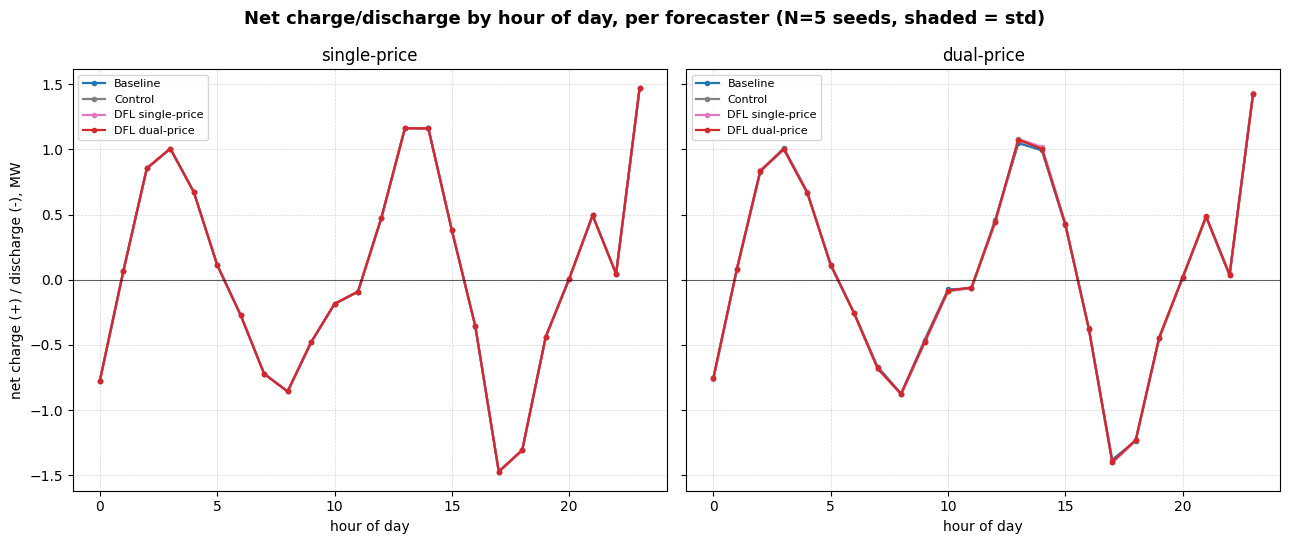

In [7]:
all_df["net"] = all_df.apply(lambda r: r["p_ch_r"] - r["p_dis_r"], axis=1)


def hourly_net_profile(market: str, family: str, seed: int) -> np.ndarray:
    """(24,) mean net profile for this market/family/seed, averaged over all test days."""
    sub = all_df[(all_df["market"] == market) & (all_df["family"] == family) & (all_df["seed"] == seed)]
    return np.stack(sub["net"].to_numpy()).mean(axis=0)


NET_RESULTS = {}   # (market, family) -> (mean (24,), std (24,) or None)
for market in ["single-price", "dual-price"]:
    for family in FAMILY_ORDER:
        seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
        per_seed = np.array([hourly_net_profile(market, family, seed) for seed in seeds])   # (n_seeds, 24)
        NET_RESULTS[(market, family)] = (per_seed.mean(axis=0), per_seed.std(axis=0) if len(seeds) > 1 else None)


def plot_hourly_net(ax, market: str):
    h = np.arange(24)
    for family in FAMILY_ORDER:
        mean, std = NET_RESULTS[(market, family)]
        ax.plot(h, mean, "-o", color=FAMILY_COLORS[family], markersize=3, label=family, linewidth=1.6)
        if std is not None:
            ax.fill_between(h, mean - std, mean + std, color=FAMILY_COLORS[family], alpha=0.15)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("hour of day")
    ax.set_title(market)
    ax.grid(linestyle="--", linewidth=0.5, alpha=0.5)
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
plot_hourly_net(axes[0], "single-price")
plot_hourly_net(axes[1], "dual-price")
axes[0].set_ylabel("net charge (+) / discharge (-), MW")
fig.suptitle("Net charge/discharge by hour of day, per forecaster (N=5 seeds, shaded = std)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

In [8]:
def sum_hourly_diff_vs_baseline(market: str, family: str) -> tuple[float, float]:
    """(mean, std) of sum_h(arm_net[h] - baseline_net[h]) over the 24 hours -- per seed
    first (that seed's own hourly profile minus Baseline's single fixed profile, summed
    over the day), then mean/std across the 5 seeds."""
    baseline_net = NET_RESULTS[(market, "Baseline")][0]   # (24,), single fixed checkpoint
    per_seed_sums = np.array([
        (hourly_net_profile(market, family, seed) - baseline_net).sum()
        for seed in SEEDS
    ])
    return float(per_seed_sums.mean()), float(per_seed_sums.std())


for market in ["single-price", "dual-price"]:
    print(f"=== {market} -- sum over 24h of (arm_net - baseline_net), MW*h ===")
    for family in RETRAIN_ARMS:
        mean, std = sum_hourly_diff_vs_baseline(market, family)
        print(f"  {family:20s} mean={mean:+.4f}  std={std:.4f}")
    print()

=== single-price -- sum over 24h of (arm_net - baseline_net), MW*h ===
  Control              mean=+0.0000  std=0.0000
  DFL single-price     mean=+0.0000  std=0.0000
  DFL dual-price       mean=+0.0000  std=0.0000

=== dual-price -- sum over 24h of (arm_net - baseline_net), MW*h ===
  Control              mean=-0.0015  std=0.0021
  DFL single-price     mean=-0.0009  std=0.0023
  DFL dual-price       mean=-0.0013  std=0.0028

